In [31]:
!pip -q install pygam

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from pygam import LogisticGAM, s

sns.set_style("whitegrid")
np.random.seed(42)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [33]:
# Load Breast Cancer Wisconsin dataset
data = load_breast_cancer()

X_full = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(
    data.target,
    name="target"
)

# Select the 6 features specified in the lab
selected_features = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean smoothness",
    "mean concavity",
    "worst area"
]

X = X_full[selected_features]

print("Dataset shape:", X.shape)

print("\nClass balance:")
print(
    y.value_counts().rename({
        0: "malignant",
        1: "benign"
    })
)

print("\nFirst five rows:")
display(X.head())

Dataset shape: (569, 6)

Class balance:
target
benign       357
malignant    212
Name: count, dtype: int64

First five rows:


,mean radius,mean texture,mean perimeter,mean smoothness,mean concavity,worst area
0,17.99,10.38,122.80,0.11840,0.3001,2019.0
1,20.57,17.77,132.90,0.08474,0.0869,1956.0
2,19.69,21.25,130.00,0.10960,0.1974,1709.0
3,11.42,20.38,77.58,0.14250,0.2414,567.7
4,20.29,14.34,135.10,0.10030,0.1980,1575.0


In [34]:
data = load_breast_cancer()

# Original dataset contains 30 variables
X_full = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

# 0 = malignant, 1 = benign
y = pd.Series(
    data.target,
    name="target"
)

print("Original dataset shape:", X_full.shape)
print("\nOriginal number of variables:", X_full.shape[1])

print("\nClass balance:")
print(
    y.value_counts().rename({
        0: "malignant",
        1: "benign"
    })
)

Original dataset shape: (569, 30)

Original number of variables: 30

Class balance:
target
benign       357
malignant    212
Name: count, dtype: int64


In [35]:
X_full["radius_area_ratio"] = (
    X_full["mean area"] /
    (np.pi * X_full["mean radius"] ** 2)
)

# Variable 32:
# Ratio between mean concavity and mean compactness
X_full["concavity_compactness_ratio"] = (
    X_full["mean concavity"] /
    (X_full["mean compactness"] + 1e-8)
)

print("\nAdded variables:")
print("31. radius_area_ratio")
print("32. concavity_compactness_ratio")


Added variables:
31. radius_area_ratio
32. concavity_compactness_ratio


In [36]:
selected_features = list(X_full.columns)

X = X_full[selected_features].copy()

print("\nFinal dataset shape:", X.shape)
print("Total variables:", len(selected_features))

print("\n", len(selected_features), "Variables:")
for i, feature in enumerate(selected_features, 1):
    print(f"{i:2d}. {feature}")


Final dataset shape: (569, 32)
Total variables: 32

 32 Variables:
 1. mean radius
 2. mean texture
 3. mean perimeter
 4. mean area
 5. mean smoothness
 6. mean compactness
 7. mean concavity
 8. mean concave points
 9. mean symmetry
10. mean fractal dimension
11. radius error
12. texture error
13. perimeter error
14. area error
15. smoothness error
16. compactness error
17. concavity error
18. concave points error
19. symmetry error
20. fractal dimension error
21. worst radius
22. worst texture
23. worst perimeter
24. worst area
25. worst smoothness
26. worst compactness
27. worst concavity
28. worst concave points
29. worst symmetry
30. worst fractal dimension
31. radius_area_ratio
32. concavity_compactness_ratio


In [37]:
print("\nMissing values:")
print(X.isnull().sum().sum())

print("\nDataset information:")
print(X.info())

print("\nFirst five rows:")
display(X.head())


Missing values:
0

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   mean radius                  569 non-null    float64
 1   mean texture                 569 non-null    float64
 2   mean perimeter               569 non-null    float64
 3   mean area                    569 non-null    float64
 4   mean smoothness              569 non-null    float64
 5   mean compactness             569 non-null    float64
 6   mean concavity               569 non-null    float64
 7   mean concave points          569 non-null    float64
 8   mean symmetry                569 non-null    float64
 9   mean fractal dimension       569 non-null    float64
 10  radius error                 569 non-null    float64
 11  texture error                569 non-null    float64
 12  perimeter error              569 non-

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,radius_area_ratio,concavity_compactness_ratio
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0.984514,1.081052
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0.997528,1.105035
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0.987698,1.234521
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0.942362,0.850299
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1.002827,1.490964


In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("\nTrain size:", X_train.shape)
print("Test size :", X_test.shape)


Train size: (426, 32)
Test size : (143, 32)


In [39]:
scaler = StandardScaler()

X_train_s = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X.columns,
    index=X_train.index
)

X_test_s = pd.DataFrame(
    scaler.transform(X_test),
    columns=X.columns,
    index=X_test.index
)

print("\nStandardization completed.")


Standardization completed.


In [40]:
print("\n" + "=" * 70)
print("EXPERIMENT 1 — LOGISTIC REGRESSION")
print("=" * 70)

logreg = LogisticRegression(
    max_iter=10000
)

logreg.fit(
    X_train_s,
    y_train
)

y_pred_lr = logreg.predict(X_test_s)

acc_lr = accuracy_score(
    y_test,
    y_pred_lr
)

print(
    f"\nLogistic Regression Test Accuracy: {acc_lr:.4f}"
)


EXPERIMENT 1 — LOGISTIC REGRESSION

Logistic Regression Test Accuracy: 0.9860


In [41]:
coef_table = pd.DataFrame({
    "feature": X.columns,
    "coefficient": logreg.coef_[0],
    "odds_ratio": np.exp(logreg.coef_[0])
})

coef_table = coef_table.sort_values(
    "coefficient",
    key=np.abs,
    ascending=False
)

print("\nLogistic Regression Coefficients:")
display(coef_table)



Logistic Regression Coefficients:


,feature,coefficient,odds_ratio
21,worst texture,-1.122923,0.325327
10,radius error,-1.017834,0.361377
30,radius_area_ratio,-0.950994,0.386357
28,worst symmetry,-0.945789,0.388373
27,worst concave points,-0.938849,0.391078
20,worst radius,-0.890279,0.410541
23,worst area,-0.797276,0.450555
13,area error,-0.778228,0.459219
26,worst concavity,-0.664788,0.514382
24,worst smoothness,-0.660841,0.516417


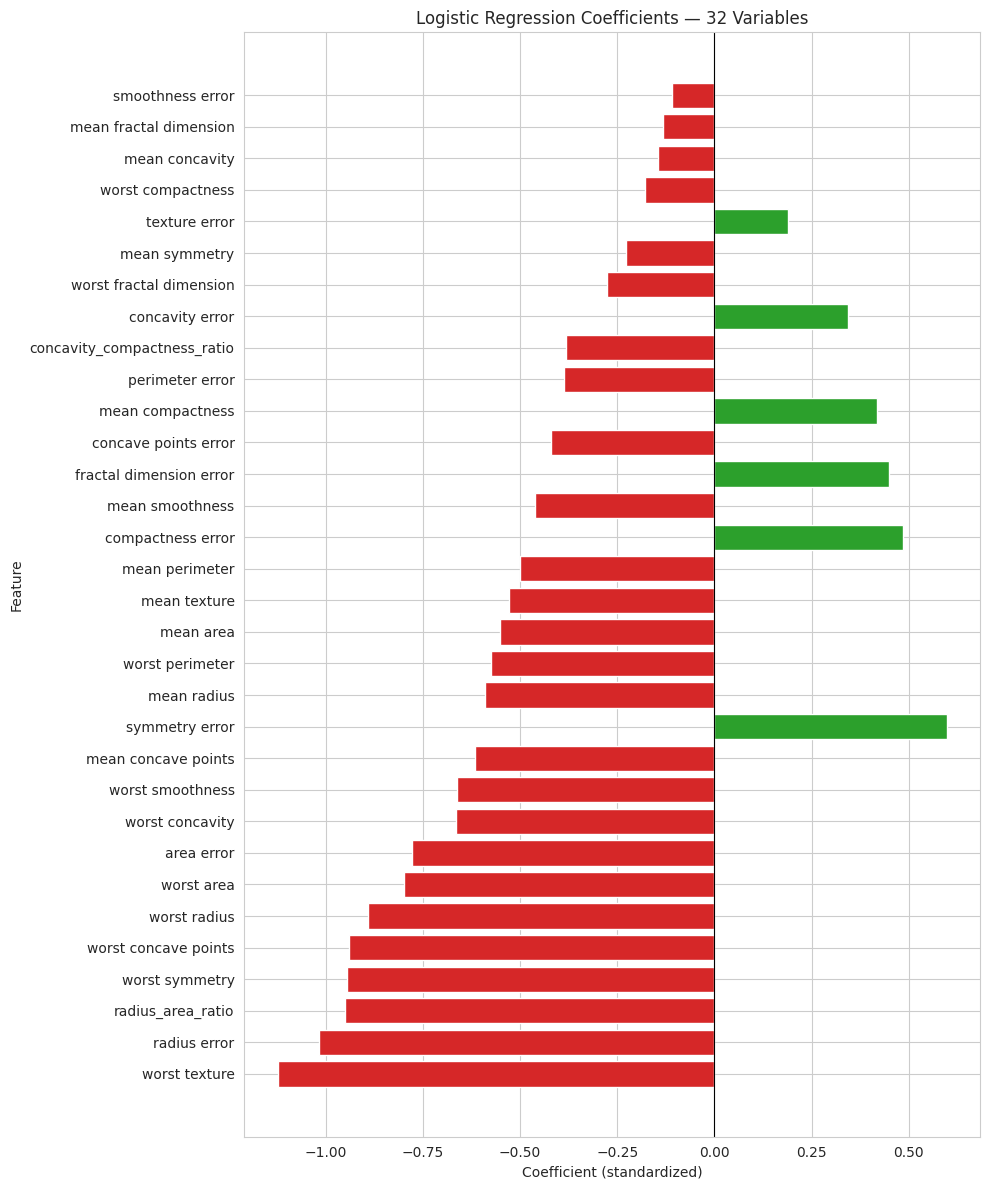

In [42]:
plt.figure(figsize=(10, 12))

colors = [
    "#d62728" if c < 0 else "#2ca02c"
    for c in coef_table["coefficient"]
]

plt.barh(
    coef_table["feature"],
    coef_table["coefficient"],
    color=colors
)

plt.axvline(
    0,
    color="black",
    linewidth=0.8
)

plt.xlabel("Coefficient (standardized)")
plt.ylabel("Feature")

plt.title(
    "Logistic Regression Coefficients — 32 Variables"
)

plt.tight_layout()
plt.show()


In [43]:
# ============================================================
# EXPERIMENT 2
# DECISION TREE
# ============================================================

print("\n" + "=" * 70)
print("EXPERIMENT 2 — DECISION TREE")
print("=" * 70)

tree = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

# Decision trees do not require standardization
tree.fit(
    X_train,
    y_train
)

y_pred_tree = tree.predict(
    X_test
)

acc_tree = accuracy_score(
    y_test,
    y_pred_tree
)

print(
    f"\nDecision Tree Test Accuracy: {acc_tree:.4f}"
)

print(
    "Tree depth:",
    tree.get_depth()
)

print(
    "Number of leaves:",
    tree.get_n_leaves()
)



EXPERIMENT 2 — DECISION TREE

Decision Tree Test Accuracy: 0.9301
Tree depth: 4
Number of leaves: 12


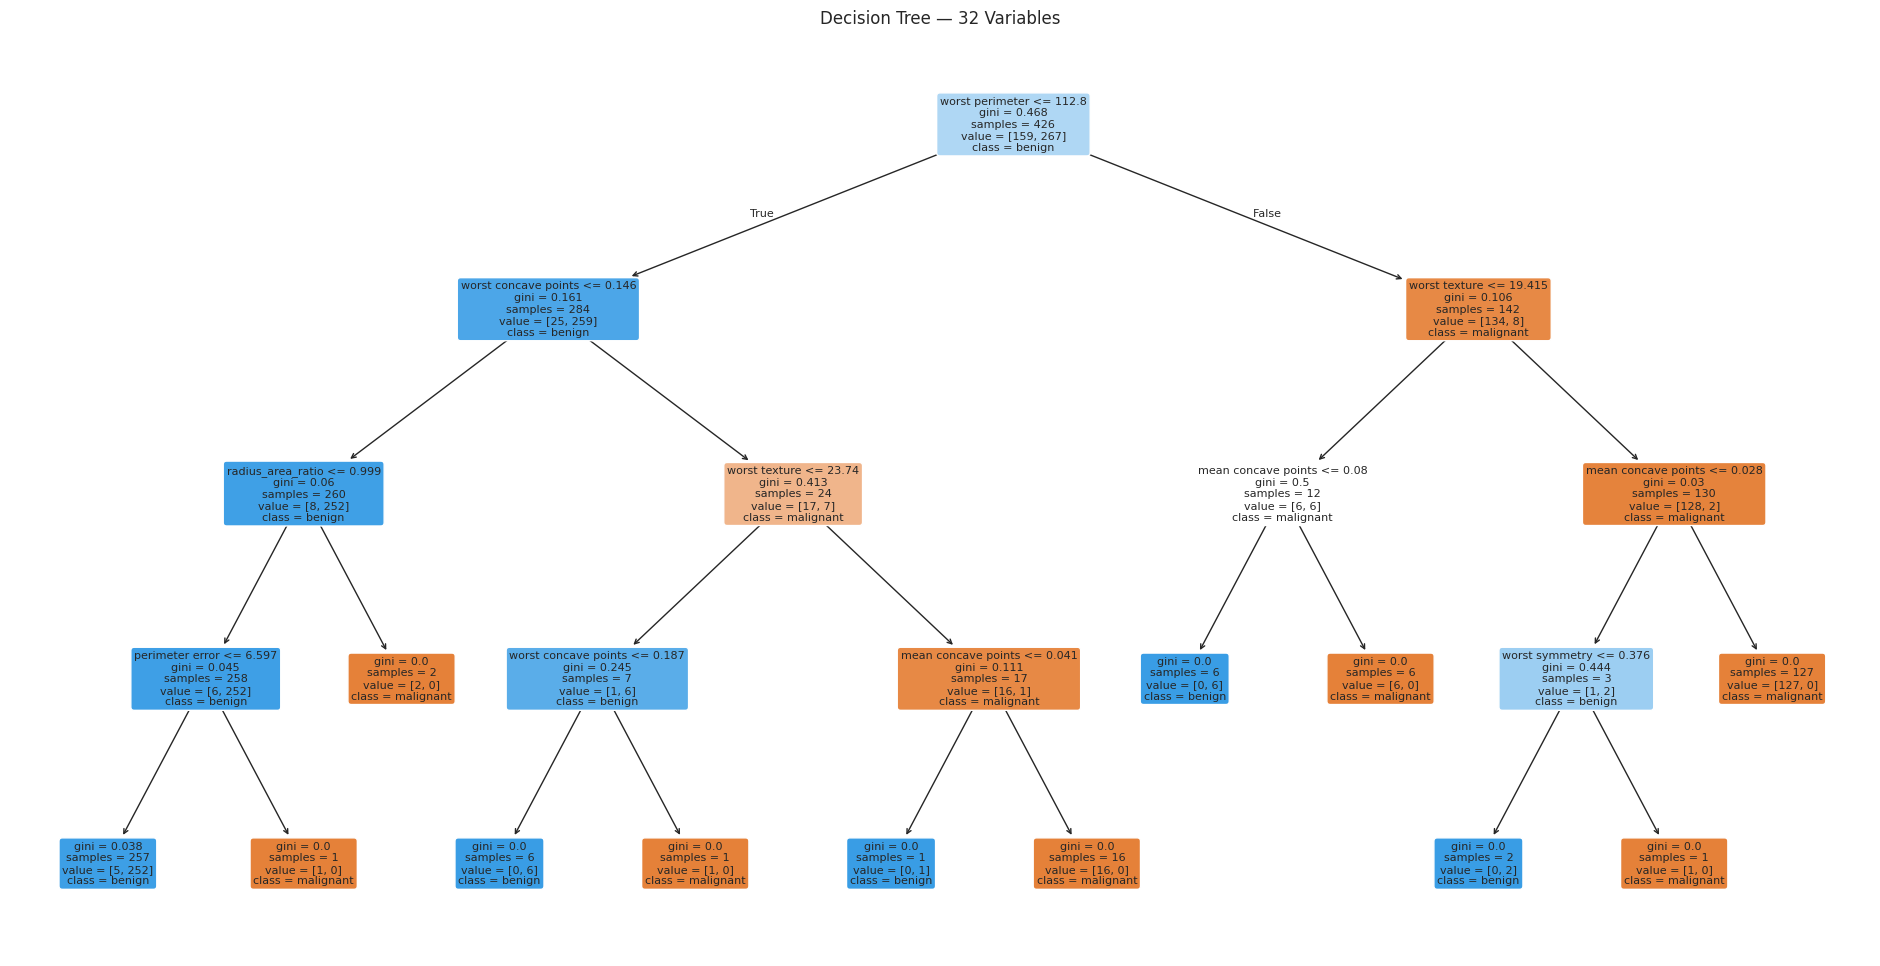

In [44]:
# ------------------------------------------------------------
# Plot decision tree
# ------------------------------------------------------------

plt.figure(figsize=(24, 12))

plot_tree(
    tree,
    feature_names=X.columns,
    class_names=["malignant", "benign"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title(
    "Decision Tree — 32 Variables"
)

plt.show()

In [45]:
# ------------------------------------------------------------
# Extract tree rules
# ------------------------------------------------------------

rules_text = export_text(
    tree,
    feature_names=list(X.columns)
)

print("\nDecision Tree Rules:")
print(rules_text)



Decision Tree Rules:
|--- worst perimeter <= 112.80
|   |--- worst concave points <= 0.15
|   |   |--- radius_area_ratio <= 1.00
|   |   |   |--- perimeter error <= 6.60
|   |   |   |   |--- class: 1
|   |   |   |--- perimeter error >  6.60
|   |   |   |   |--- class: 0
|   |   |--- radius_area_ratio >  1.00
|   |   |   |--- class: 0
|   |--- worst concave points >  0.15
|   |   |--- worst texture <= 23.74
|   |   |   |--- worst concave points <= 0.19
|   |   |   |   |--- class: 1
|   |   |   |--- worst concave points >  0.19
|   |   |   |   |--- class: 0
|   |   |--- worst texture >  23.74
|   |   |   |--- mean concave points <= 0.04
|   |   |   |   |--- class: 1
|   |   |   |--- mean concave points >  0.04
|   |   |   |   |--- class: 0
|--- worst perimeter >  112.80
|   |--- worst texture <= 19.41
|   |   |--- mean concave points <= 0.08
|   |   |   |--- class: 1
|   |   |--- mean concave points >  0.08
|   |   |   |--- class: 0
|   |--- worst texture >  19.41
|   |   |--- mean conc

In [46]:
# ============================================================
# EXPERIMENT 3
# EXPLICIT RULE EXTRACTION
# ============================================================

print("\n" + "=" * 70)
print("EXPERIMENT 3 — RULE EXTRACTION")
print("=" * 70)


def extract_rules(
    tree_model,
    feature_names,
    class_names
):

    tree_ = tree_model.tree_

    feature_name = [
        feature_names[i]
        if i != -2
        else "undefined!"
        for i in tree_.feature
    ]

    rules = []

    def recurse(
        node,
        conditions
    ):

        # Non-leaf node
        if tree_.feature[node] != -2:

            name = feature_name[node]

            threshold = tree_.threshold[node]

            # Left branch
            recurse(
                tree_.children_left[node],
                conditions + [
                    f"({name} <= {threshold:.4f})"
                ]
            )

            # Right branch
            recurse(
                tree_.children_right[node],
                conditions + [
                    f"({name} > {threshold:.4f})"
                ]
            )

        # Leaf node
        else:

            counts = tree_.value[node][0]

            predicted_class = class_names[
                int(np.argmax(counts))
            ]

            confidence = (
                counts.max() /
                counts.sum()
            )

            rule = (
                "IF " +
                " AND ".join(conditions)
                if conditions
                else "TRUE"
            )

            rules.append(
                f"{rule} => "
                f"predict '{predicted_class}' "
                f"(confidence={confidence:.2f}, "
                f"n={int(counts.sum())})"
            )

    recurse(0, [])

    return rules


rule_list = extract_rules(
    tree,
    list(X.columns),
    ["malignant", "benign"]
)

for i, rule in enumerate(
    rule_list,
    1
):

    print(
        f"Rule {i}: {rule}"
    )

print(
    f"\nTotal number of rules: {len(rule_list)}"
)



EXPERIMENT 3 — RULE EXTRACTION
Rule 1: IF (worst perimeter <= 112.8000) AND (worst concave points <= 0.1456) AND (radius_area_ratio <= 0.9992) AND (perimeter error <= 6.5975) => predict 'benign' (confidence=0.98, n=1)
Rule 2: IF (worst perimeter <= 112.8000) AND (worst concave points <= 0.1456) AND (radius_area_ratio <= 0.9992) AND (perimeter error > 6.5975) => predict 'malignant' (confidence=1.00, n=1)
Rule 3: IF (worst perimeter <= 112.8000) AND (worst concave points <= 0.1456) AND (radius_area_ratio > 0.9992) => predict 'malignant' (confidence=1.00, n=1)
Rule 4: IF (worst perimeter <= 112.8000) AND (worst concave points > 0.1456) AND (worst texture <= 23.7400) AND (worst concave points <= 0.1868) => predict 'benign' (confidence=1.00, n=1)
Rule 5: IF (worst perimeter <= 112.8000) AND (worst concave points > 0.1456) AND (worst texture <= 23.7400) AND (worst concave points > 0.1868) => predict 'malignant' (confidence=1.00, n=1)
Rule 6: IF (worst perimeter <= 112.8000) AND (worst conca

In [47]:
# ============================================================
# EXPERIMENT 4
# k-NEAREST NEIGHBORS
# ============================================================

print("\n" + "=" * 70)
print("EXPERIMENT 4 — k-NEAREST NEIGHBORS")
print("=" * 70)

knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(
    X_train_s,
    y_train
)

y_pred_knn = knn.predict(
    X_test_s
)

acc_knn = accuracy_score(
    y_test,
    y_pred_knn
)

print(
    f"\nk-NN Test Accuracy: {acc_knn:.4f}"
)


EXPERIMENT 4 — k-NEAREST NEIGHBORS

k-NN Test Accuracy: 0.9860


In [48]:
# ------------------------------------------------------------
# Explain one prediction
# ------------------------------------------------------------

sample_idx = 0

sample = X_test_s.iloc[
    [sample_idx]
]

true_label = y_test.iloc[
    sample_idx
]

pred_label = knn.predict(
    sample
)[0]

distances, neighbor_idx = knn.kneighbors(
    sample,
    n_neighbors=5
)

neighbor_labels = (
    y_train.iloc[
        neighbor_idx[0]
    ].values
)

print(
    f"\nTest sample #{sample_idx}"
)

print(
    "True label:",
    true_label
)

print(
    "Predicted label:",
    pred_label
)

print(
    "Labels of 5 nearest neighbors:",
    neighbor_labels
)

print(
    "\nExplanation:"
)

print(
    "The prediction is based on the majority "
    "vote of the 5 most similar training samples."
)


neighbor_table = X_train.iloc[
    neighbor_idx[0]
].copy()

neighbor_table["distance"] = distances[0]

neighbor_table["label"] = neighbor_labels

print("\nNearest Neighbor Details:")
display(neighbor_table)



Test sample #0
True label: 1
Predicted label: 1
Labels of 5 nearest neighbors: [1 1 1 1 1]

Explanation:
The prediction is based on the majority vote of the 5 most similar training samples.

Nearest Neighbor Details:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,radius_area_ratio,concavity_compactness_ratio,distance,label
502,12.54,16.32,81.25,476.3,0.1158,0.10850,0.05928,0.03279,0.1943,0.06612,...,0.1580,0.1751,0.1889,0.08411,0.3155,0.07538,0.964130,0.546359,2.043811,1
249,11.52,14.93,73.87,406.3,0.1013,0.07808,0.04328,0.02929,0.1883,0.06168,...,0.1389,0.1582,0.1804,0.09608,0.2664,0.07809,0.974523,0.554303,2.271233,1
394,12.10,17.72,78.07,446.2,0.1029,0.09758,0.04783,0.03326,0.1937,0.06161,...,0.1432,0.1773,0.1603,0.06266,0.3049,0.07081,0.970083,0.490162,2.272643,1
422,11.61,16.02,75.46,408.2,0.1088,0.11680,0.07097,0.04497,0.1886,0.06320,...,0.1415,0.2170,0.2302,0.11050,0.2787,0.07427,0.963959,0.607620,2.302744,1
221,13.56,13.90,88.59,561.3,0.1051,0.11920,0.07860,0.04451,0.1962,0.06303,...,0.1376,0.2698,0.2577,0.09090,0.3065,0.08177,0.971686,0.659396,2.343917,1


In [49]:
# ============================================================
# EXPERIMENT 5
# GAUSSIAN NAIVE BAYES
# ============================================================

print("\n" + "=" * 70)
print("EXPERIMENT 5 — GAUSSIAN NAIVE BAYES")
print("=" * 70)

nb = GaussianNB()

nb.fit(
    X_train_s,
    y_train
)

y_pred_nb = nb.predict(
    X_test_s
)

acc_nb = accuracy_score(
    y_test,
    y_pred_nb
)

print(
    f"\nGaussian Naive Bayes Test Accuracy: {acc_nb:.4f}"
)



EXPERIMENT 5 — GAUSSIAN NAIVE BAYES

Gaussian Naive Bayes Test Accuracy: 0.9371


In [50]:
# ------------------------------------------------------------
# Learned parameters
# ------------------------------------------------------------

nb_params = pd.DataFrame(
    nb.theta_,
    columns=X.columns,
    index=["malignant", "benign"]
)

print(
    "\nLearned per-class feature means:"
)

display(nb_params)


Learned per-class feature means:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,radius_area_ratio,concavity_compactness_ratio
malignant,0.949431,0.528204,0.966140,0.925456,0.511243,0.791618,0.896919,1.015759,0.458913,-0.012224,...,1.011579,0.952863,0.549990,0.781336,0.864008,1.032417,0.560769,0.424609,0.409852,0.888648
benign,-0.565392,-0.314548,-0.575342,-0.551114,-0.304448,-0.471413,-0.534120,-0.604890,-0.273285,0.007280,...,-0.602401,-0.567435,-0.327522,-0.465290,-0.514521,-0.614810,-0.333941,-0.252857,-0.244069,-0.529195


In [51]:
# ============================================================
# EXPERIMENT 6
# GENERALIZED ADDITIVE MODEL
# ============================================================

print("\n" + "=" * 70)
print("EXPERIMENT 6 — GENERALIZED ADDITIVE MODEL")
print("=" * 70)


EXPERIMENT 6 — GENERALIZED ADDITIVE MODEL


In [52]:
# ------------------------------------------------------------
# Automatically create 32 spline terms
# ------------------------------------------------------------

n_features = X.shape[1]

gam_terms = s(0)

for i in range(1, n_features):
    gam_terms = gam_terms + s(i)


print(
    f"Creating GAM with {n_features} feature terms..."
)


gam = LogisticGAM(
    gam_terms
).fit(
    X_train_s.values,
    y_train.values
)

Creating GAM with 32 feature terms...
did not converge


In [53]:
# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

y_pred_gam = (
    gam.predict_mu(
        X_test_s.values
    ) > 0.5
).astype(int)


acc_gam = accuracy_score(
    y_test,
    y_pred_gam
)

print(
    f"\nGAM Test Accuracy: {acc_gam:.4f}"
)


GAM Test Accuracy: 0.9860



Generating GAM shape functions...


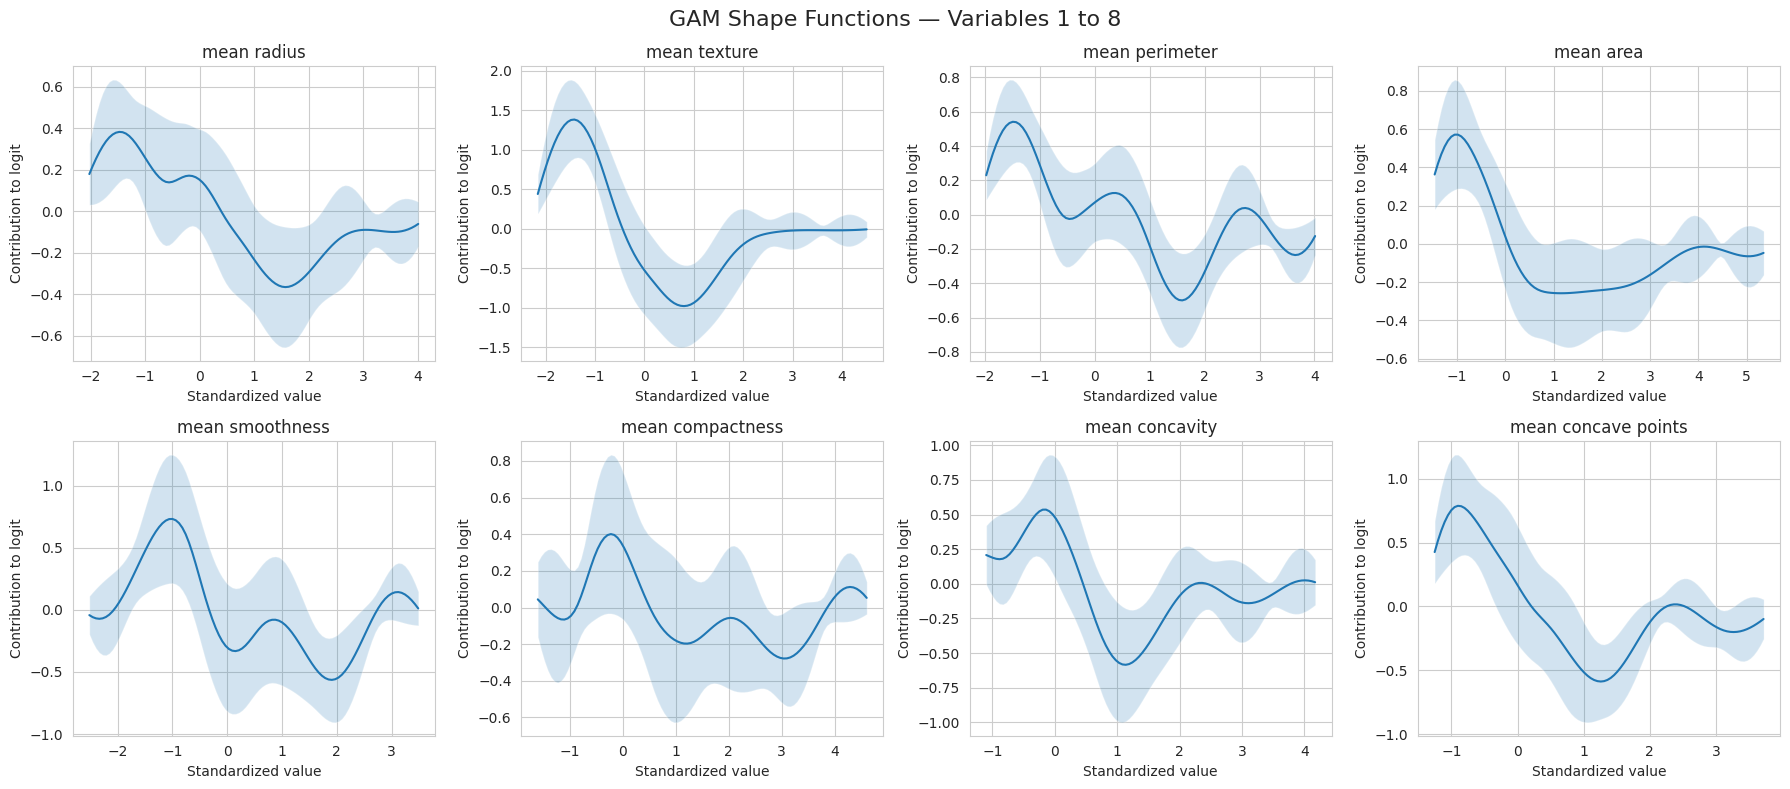

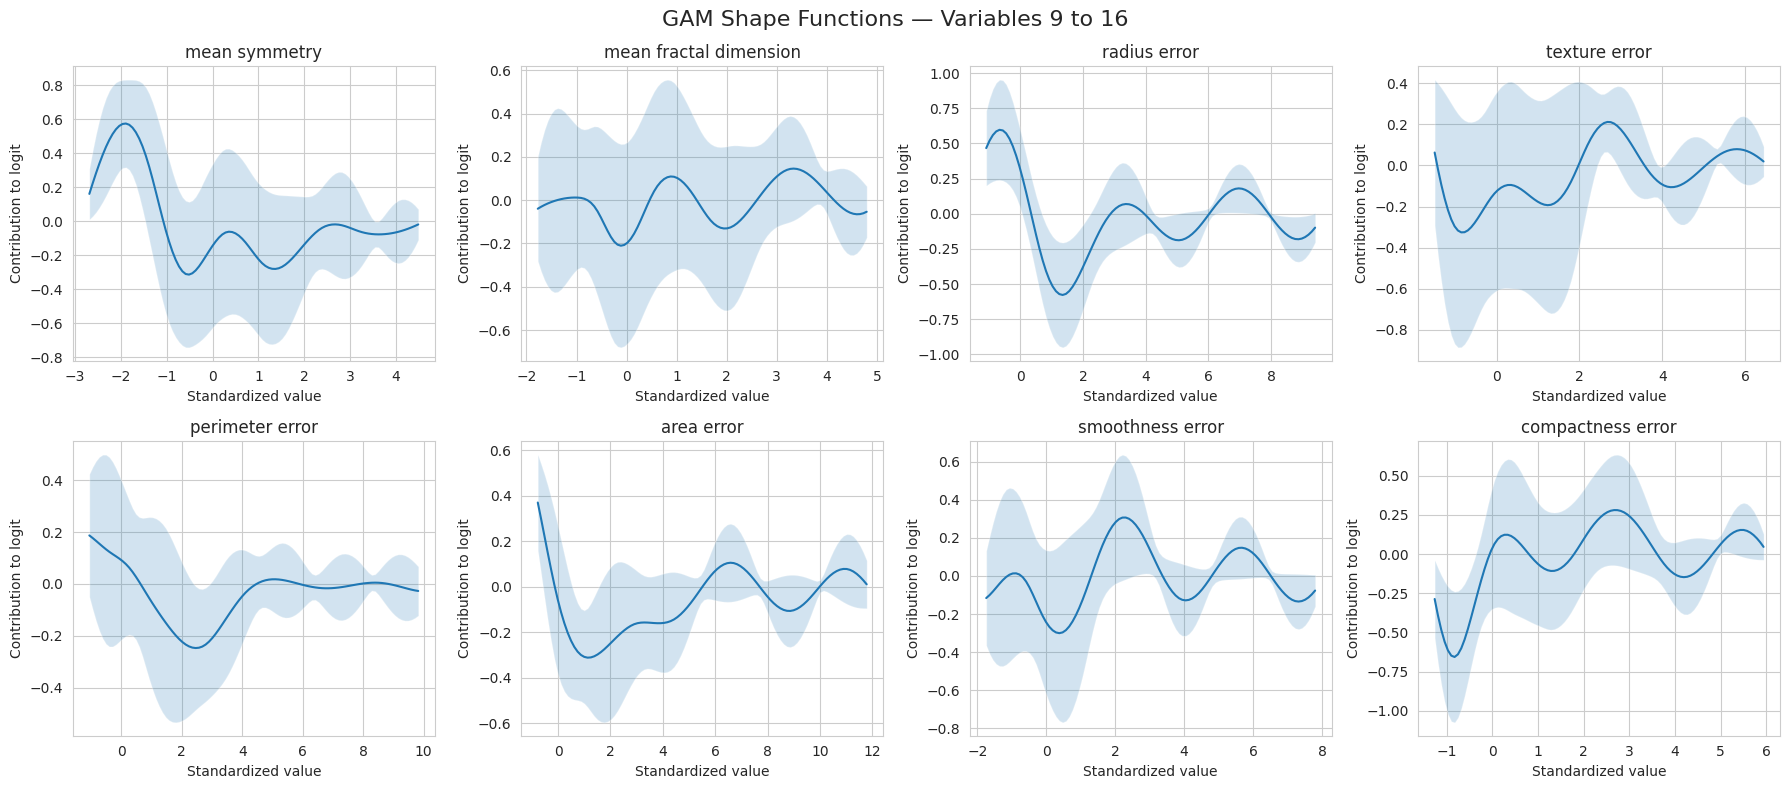

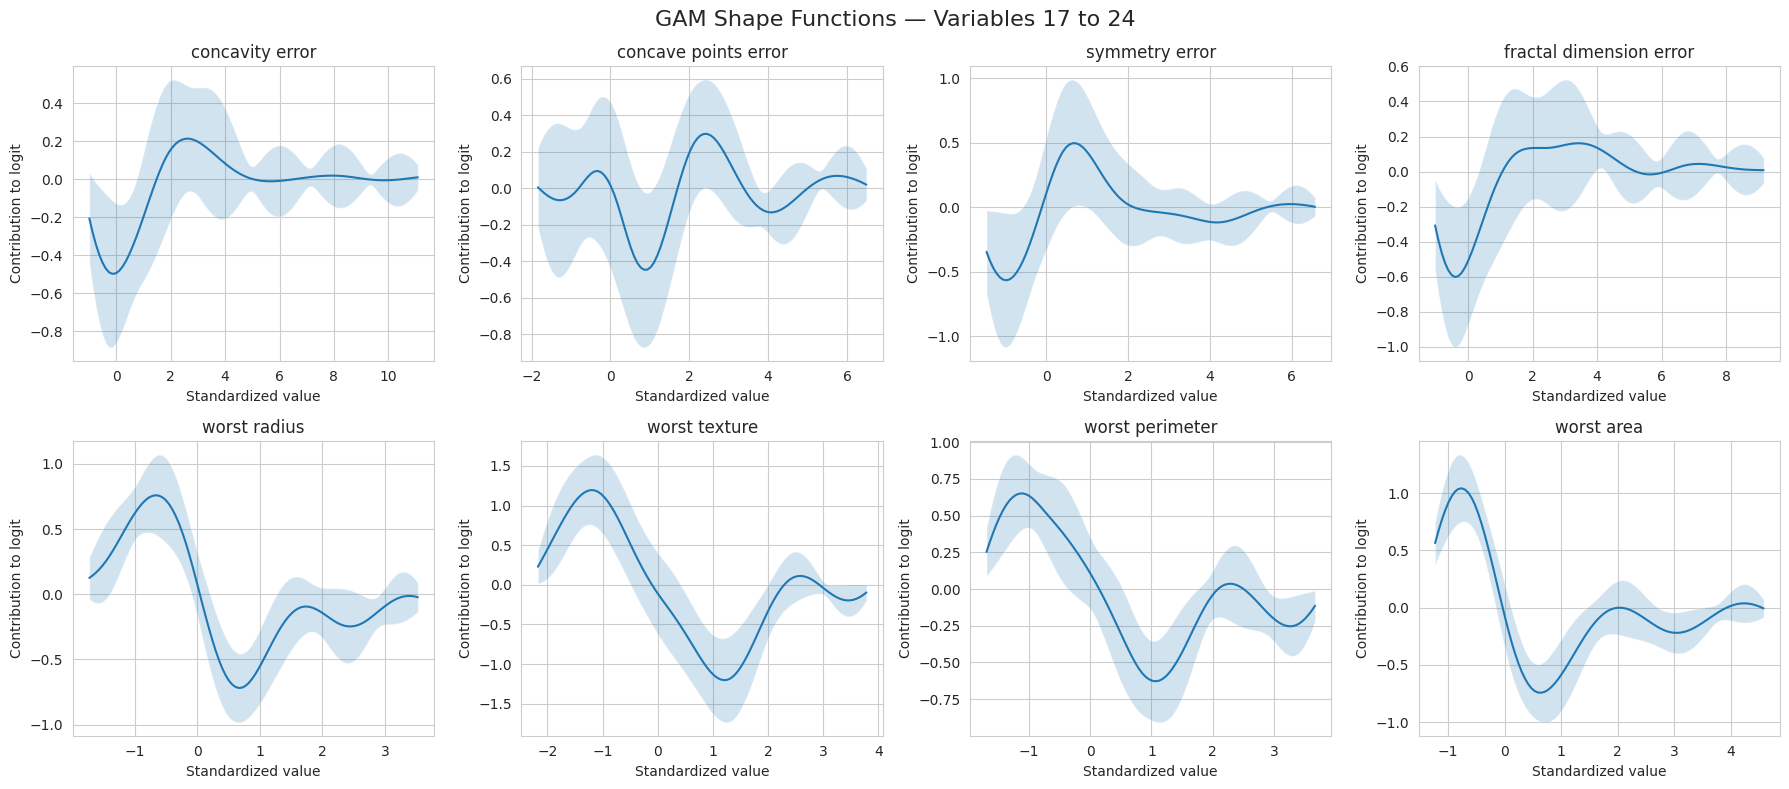

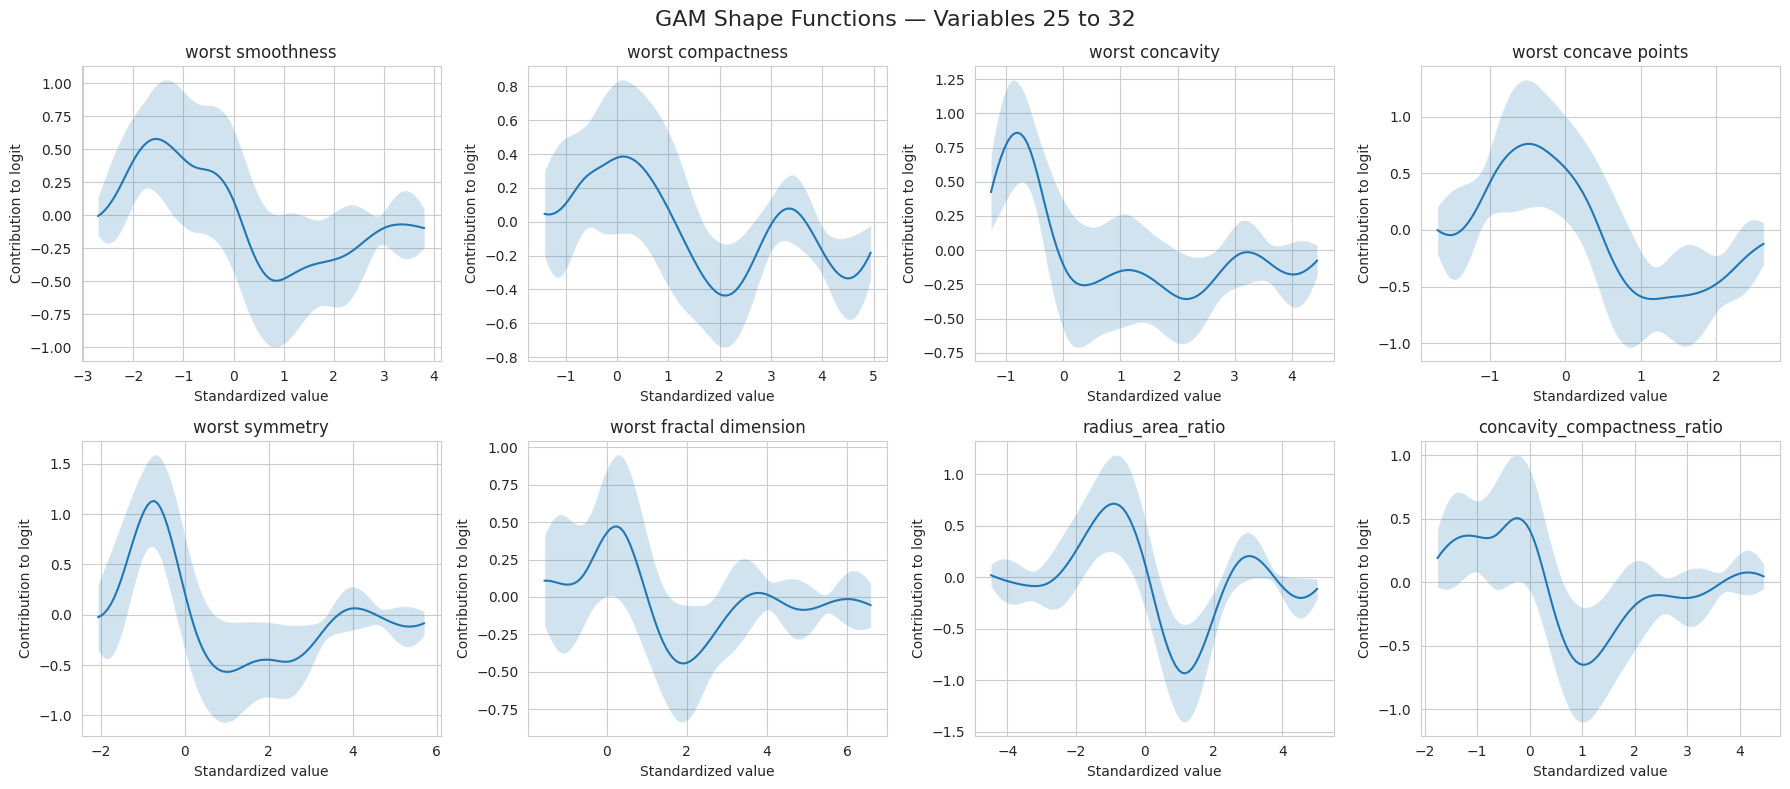

In [54]:
# ============================================================
# GAM SHAPE FUNCTIONS
# ============================================================

print("\nGenerating GAM shape functions...")


# Plot 32 features in groups of 8
# This avoids creating one extremely large figure.

for start in range(
    0,
    n_features,
    8
):

    end = min(
        start + 8,
        n_features
    )

    number_of_plots = end - start

    rows = 2
    cols = 4

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(18, 8)
    )

    axes = axes.ravel()

    for local_i, feature_i in enumerate(
        range(start, end)
    ):

        XX = gam.generate_X_grid(
            term=feature_i
        )

        pdep, confi = gam.partial_dependence(
            term=feature_i,
            X=XX,
            width=0.95
        )

        axes[local_i].plot(
            XX[:, feature_i],
            pdep
        )

        axes[local_i].fill_between(
            XX[:, feature_i],
            confi[:, 0],
            confi[:, 1],
            alpha=0.2
        )

        axes[local_i].set_title(
            X.columns[feature_i]
        )

        axes[local_i].set_xlabel(
            "Standardized value"
        )

        axes[local_i].set_ylabel(
            "Contribution to logit"
        )

    # Hide unused axes
    for j in range(
        number_of_plots,
        len(axes)
    ):
        axes[j].axis("off")

    plt.suptitle(
        f"GAM Shape Functions — Variables {start + 1} to {end}",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()


In [55]:
# ============================================================
# MODEL EVALUATION
# ============================================================

print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)


results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "k-NN",
        "Gaussian Naive Bayes",
        "GAM"
    ],

    "Test Accuracy": [
        acc_lr,
        acc_tree,
        acc_knn,
        acc_nb,
        acc_gam
    ],

    "Interpretability Unit": [
        "Coefficient",
        "Rule / Leaf",
        "Neighbor Set",
        "Per-feature likelihood",
        "Shape Function"
    ],

    "Number of Units": [
        len(X.columns),
        tree.get_n_leaves(),
        5,
        len(X.columns),
        len(X.columns)
    ],

    "Simulatable by Hand?": [
        "Yes",
        "Yes",
        "Yes (local)",
        "Yes",
        "Yes (with plot)"
    ]
})


results = results.sort_values(
    "Test Accuracy",
    ascending=False
).reset_index(
    drop=True
)

display(results)


MODEL COMPARISON


,Model,Test Accuracy,Interpretability Unit,Number of Units,Simulatable by Hand?
0,Logistic Regression,0.986014,Coefficient,32,Yes
1,k-NN,0.986014,Neighbor Set,5,Yes (local)
2,GAM,0.986014,Shape Function,32,Yes (with plot)
3,Gaussian Naive Bayes,0.937063,Per-feature likelihood,32,Yes
4,Decision Tree,0.930070,Rule / Leaf,12,Yes


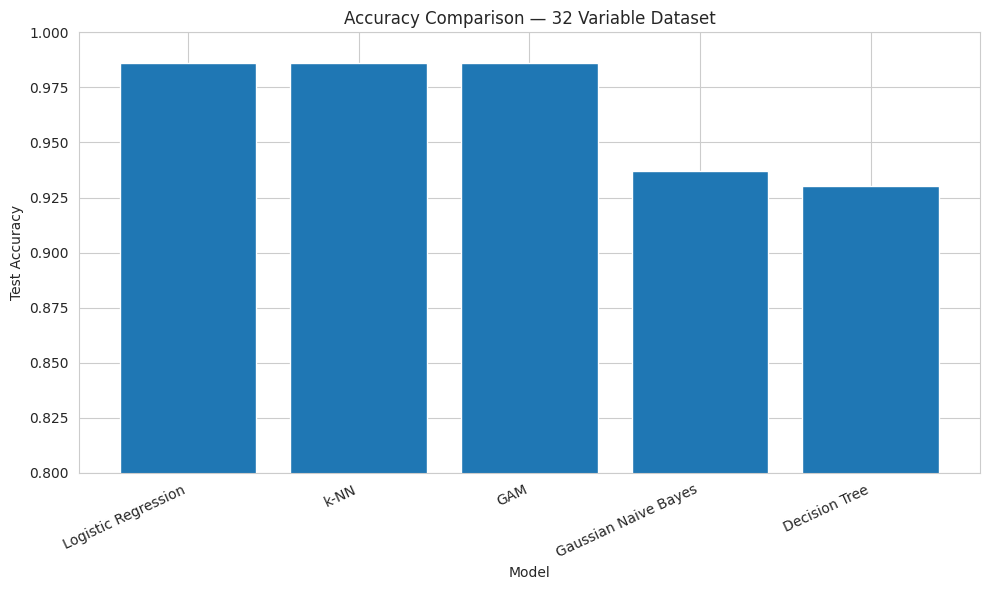

In [56]:
# ============================================================
# ACCURACY COMPARISON
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    results["Model"],
    results["Test Accuracy"]
)

plt.ylim(
    0.80,
    1.00
)

plt.ylabel(
    "Test Accuracy"
)

plt.xlabel(
    "Model"
)

plt.title(
    "Accuracy Comparison — 32 Variable Dataset"
)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.tight_layout()

plt.show()


In [57]:
# ============================================================
# CLASSIFICATION REPORTS
# ============================================================

print("\n" + "=" * 70)
print("CLASSIFICATION REPORTS")
print("=" * 70)


model_predictions = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_tree,
    "k-NN": y_pred_knn,
    "Gaussian Naive Bayes": y_pred_nb,
    "GAM": y_pred_gam
}


for model_name, predictions in model_predictions.items():

    print(
        f"\n{'-' * 60}"
    )

    print(
        model_name
    )

    print(
        f"{'-' * 60}"
    )

    print(
        classification_report(
            y_test,
            predictions,
            target_names=[
                "malignant",
                "benign"
            ]
        )
    )



CLASSIFICATION REPORTS

------------------------------------------------------------
Logistic Regression
------------------------------------------------------------
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        53
      benign       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143


------------------------------------------------------------
Decision Tree
------------------------------------------------------------
              precision    recall  f1-score   support

   malignant       0.92      0.89      0.90        53
      benign       0.93      0.96      0.95        90

    accuracy                           0.93       143
   macro avg       0.93      0.92      0.92       143
weighted avg       0.93      0.93      0.93       143


-----------------------------------------


Best model based on test accuracy: Logistic Regression


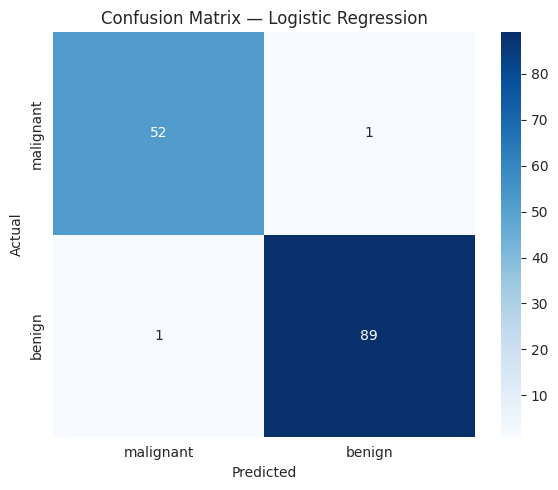

In [58]:
# ============================================================
# CONFUSION MATRIX — BEST MODEL
# ============================================================

best_model_name = results.iloc[0]["Model"]

print(
    "\nBest model based on test accuracy:",
    best_model_name
)


best_predictions = model_predictions[
    best_model_name
]

cm = confusion_matrix(
    y_test,
    best_predictions
)

plt.figure(
    figsize=(6, 5)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "malignant",
        "benign"
    ],
    yticklabels=[
        "malignant",
        "benign"
    ]
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    f"Confusion Matrix — {best_model_name}"
)

plt.tight_layout()

plt.show()


In [59]:
# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FINAL SUMMARY")
print("=" * 70)

print(
    f"Original variables : 30"
)

print(
    f"Additional variables: 2"
)

print(
    f"Final variables     : {X.shape[1]}"
)

print(
    f"Training samples    : {X_train.shape[0]}"
)

print(
    f"Testing samples     : {X_test.shape[0]}"
)

print(
    f"\nBest model: {best_model_name}"
)

print(
    f"Best test accuracy: "
    f"{results.iloc[0]['Test Accuracy']:.4f}"
)


FINAL SUMMARY
Original variables : 30
Additional variables: 2
Final variables     : 32
Training samples    : 426
Testing samples     : 143

Best model: Logistic Regression
Best test accuracy: 0.9860
